# Classification of Blogs

In [1]:
!pip install mlflow

  Using cached matplotlib-3.10.8-cp310-cp310-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached pandas-2.3.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached pyarrow-23.0.1-cp310-cp310-macosx_12_0_arm64.whl.metadata (3.1 kB)
  Using cached cachetools-7.0.5-py3-none-any.whl.metadata (5.6 kB)
  Using cached click-8.3.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached protobuf-6.33.6-cp39-abi3-macosx_10_9_universal2.whl.metadata (593 bytes)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached werkzeug-3.1.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm

In [2]:
!pip install pyngrok

In [6]:
!pip install seaborn 
!pip install nltk

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.0 MB/s eta 0:00:00a 0:00:01


In [7]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier, LogisticRegression

import mlflow
import mlflow.sklearn

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adithyan/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [47]:
train_df=pd.read_csv("./dataset/test.csv",header=0,names=['classid','title','desc'])
test_df=pd.read_csv("dataset/test.csv",header=0,names=['classid','title','desc'])


In [9]:
train_df.head()

,classid,title,desc
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [10]:
test_df.head()

,classid,title,desc
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [11]:
train_df['text'] = train_df['title'] + " " + train_df['desc']
test_df['text'] = test_df['title'] + " " + test_df['desc']

In [12]:
train_x = train_df['text']
train_y = train_df['classid']

test_x = test_df['text']
test_y = test_df['classid']

In [13]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()

    # remove special characters
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [14]:
train_x = train_x.apply(preprocess)
test_x = test_x.apply(preprocess)

print(train_x.head())  # MUST look like normal words

0    wall st bears claw back black reuters reuters ...
1    carlyle looks toward commercial aerospace reut...
2    oil economy cloud stocks outlook reuters reute...
3    iraq halts oil exports main southern pipeline ...
4    oil prices soar alltime record posing new mena...
Name: text, dtype: object


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)  # limit features (better performance)

train_vec = tfidf.fit_transform(train_x)
test_vec = tfidf.transform(test_x)

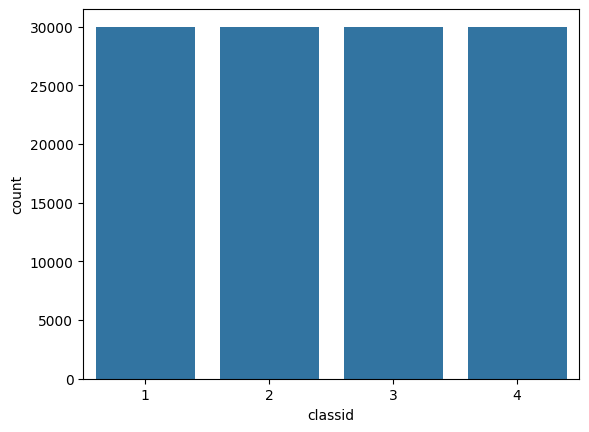

In [16]:
sns.countplot(x=train_y)
plt.show()

In [17]:
tfidf = TfidfVectorizer(min_df=3)

train_vec = tfidf.fit_transform(train_x)
test_vec = tfidf.transform(test_x)

print("Features:", len(tfidf.get_feature_names_out()))

Features: 37053


In [45]:
import mlflow
import mlflow.sklearn

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import LinearSVC

# -------------------------------
# MLflow Setup
# -------------------------------
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("News Classification Advanced")

# -------------------------------
# Tuned Models
# -------------------------------
models = {
    "Naive_Bayes": MultinomialNB(alpha=0.5),
    "SGD": SGDClassifier(alpha=0.0001, max_iter=1000),
    "Logistic_Regression": LogisticRegression(max_iter=1000, C=1.0),
    "SVM": LinearSVC(C=1.0)
}

best_model = None
best_score = 0
best_name = ""

# -------------------------------
# Training Loop
# -------------------------------
for name, model in models.items():

    with mlflow.start_run(run_name=name):

        # Train
        model.fit(train_vec, train_y)

        # Predict
        pred = model.predict(test_vec)

        # Metrics
        acc = accuracy_score(test_y, pred)
        precision = precision_score(test_y, pred, average='weighted')
        recall = recall_score(test_y, pred, average='weighted')
        f1 = f1_score(test_y, pred, average='weighted')

        # Log params
        mlflow.log_param("model", name)

        # Log metrics
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)

        # Log model
        mlflow.sklearn.log_model(model, name="model")

        print(f"{name} → Accuracy: {acc:.4f}")

        # Track best model
        if acc > best_score:
            best_score = acc
            best_model = model
            best_name = name

# -------------------------------
# Log Best Model Separately
# -------------------------------
with mlflow.start_run(run_name="BEST_MODEL"):

    mlflow.log_param("best_model", best_name)
    mlflow.log_metric("best_accuracy", best_score)

    mlflow.sklearn.log_model(best_model, name="best_model")

print("\n🔥 BEST MODEL:", best_name)
print("🔥 BEST ACCURACY:", best_score)

2026/04/19 20:43:47 INFO mlflow.tracking.fluent: Experiment with name 'News Classification Advanced' does not exist. Creating a new experiment.
2026/04/19 20:43:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Naive_Bayes → Accuracy: 0.9032


2026/04/19 20:43:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SGD → Accuracy: 0.9108


2026/04/19 20:43:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic_Regression → Accuracy: 0.9183


2026/04/19 20:43:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/19 20:44:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SVM → Accuracy: 0.9189

🔥 BEST MODEL: SVM
🔥 BEST ACCURACY: 0.9189473684210526


In [46]:
!mlflow ui \
--host 127.0.0.1 \
--port 5001 \
--allowed-hosts '*' \
--cors-allowed-origins '*'

Backend store URI not provided. Using ./mlruns
Registry store URI not provided. Using backend store URI.
/opt/anaconda3/envs/gpt-notebook/lib/python3.10/site-packages/mlflow/server/handlers.py:377: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, artifact_uri)
/opt/anaconda3/envs/gpt-notebook/lib/python3.10/site-packages/mlflow/server/handlers.py:412: FutureWarning: The filesystem model registry backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStor